# About

This notebook computes the distance matrix given by the phylogenetic tree of the pre-published MetaPhlAn4 SGBs.
The input are two files:

- mpa_vJan21_CHOCOPhlAnSGB_202103.nwk
- MetaPhlAn4_paper_profile_SGBs.txt

The required python modules are:

- dendropy (for fast tree loading and leaf-node pruning)
- phylodm (for fast distance calculations, but lacks built-in tree pruning)

In [1]:
from pathlib import Path
import numpy as np

# Load tree with DendroPy (faster for large trees)
data_dir = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/dataset")
NEWICK_FILE = data_dir / 'mpa_vJan21_CHOCOPhlAnSGB_202103.nwk'
SGB_SUBSET_ID_PATH = data_dir / "MetaPhlAn4_paper_profile_SGBs.txt"
PRUNED_TREE_PATH = data_dir / "MetaPhlAn4_paper_profile_SGBs.TREE.nwk"
DISTMAT_PATH = data_dir / "MetaPhlAn4_paper_profile_SGBs.DIST_MATRIX.npz"

In [2]:
""" load the taxa subset. """
with open(SGB_SUBSET_ID_PATH, "rt") as f:
    target_leaf_names = [l.strip() for l in f]
target_leaf_names = [x for x in target_leaf_names if len(x) > 0]


def cleanup_id(x: str) -> str:
    if x.startswith("SGB"):
        x = x[3:]
    if x.endswith("_group"):
        x = x[:-len("_group")]
    return x
target_leaf_names = [cleanup_id(sgb_id) for sgb_id in target_leaf_names]

print("Target leaf names:", len(target_leaf_names))

Target leaf names: 11170


In [3]:
""" Prune the tree leaf nodes, and save it. """
import dendropy

tree = dendropy.Tree.get(path=str(NEWICK_FILE), schema='newick')

# Get taxa to retain
taxa_to_retain = [taxon for taxon in tree.taxon_namespace if taxon.label in target_leaf_names]

# Prune tree to only these taxa
print("Pruning tree.")
tree.retain_taxa(taxa_to_retain)

# Write the tree to a file in Newick format
tree.write_to_path(PRUNED_TREE_PATH, "newick")

Pruning tree.


In [4]:
""" Validate the newly pruned tree. """
tree2 = dendropy.Tree.get(path=PRUNED_TREE_PATH, schema='newick')
print("tree2 leaves:", len(tree2.taxon_namespace))
assert len(tree2.taxon_namespace) == len(taxa_to_retain)

tree2 leaves: 11124


In [5]:
""" Calculate the distance matrix. """

from phylodm import PhyloDM

# 1a. From a Newick file
pdm = PhyloDM.load_from_newick_path(PRUNED_TREE_PATH)
dm = pdm.dm(norm=False)
labels = pdm.taxa()

Unable to load newick tree using light_phylogeny (Rust). This is likely due to it not supporting the extended Newick format... falling back to DendroPy to load the tree.


In [6]:
""" Save the distance matrix. """
np.savez(DISTMAT_PATH, mat=dm, labels=labels)

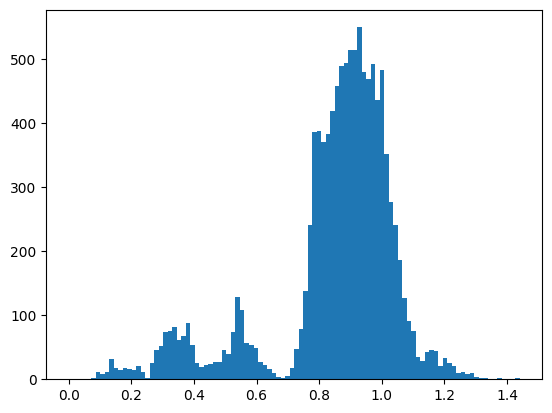

In [28]:
import matplotlib.pyplot as plt

_ = plt.hist(dm[6000, :], bins=100)